## HiGHS

**Concepts:** [Exact optimization](../routers.md#exact-optimization) **Reference:** [MILP Solvers](../reference/solvers.md) **Network/Router API:** [🎯 MILPRouter](hi23_milp.ipynb)

Solving the MILP model with HiGHS (open source). The approach and the full solver roster are described in [Exact optimization](../routers.md#exact-optimization), the model options in [Model options](../routers.md#model-options), and the installation steps in [Install](../install.md).

In [1]:
from optiwindnet.heuristics import constructor
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import G_from_S
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.svg import svgplot

### Initialize Triton

In [2]:
locations = load_repository()

In [3]:
L = locations.triton
capacity = 8

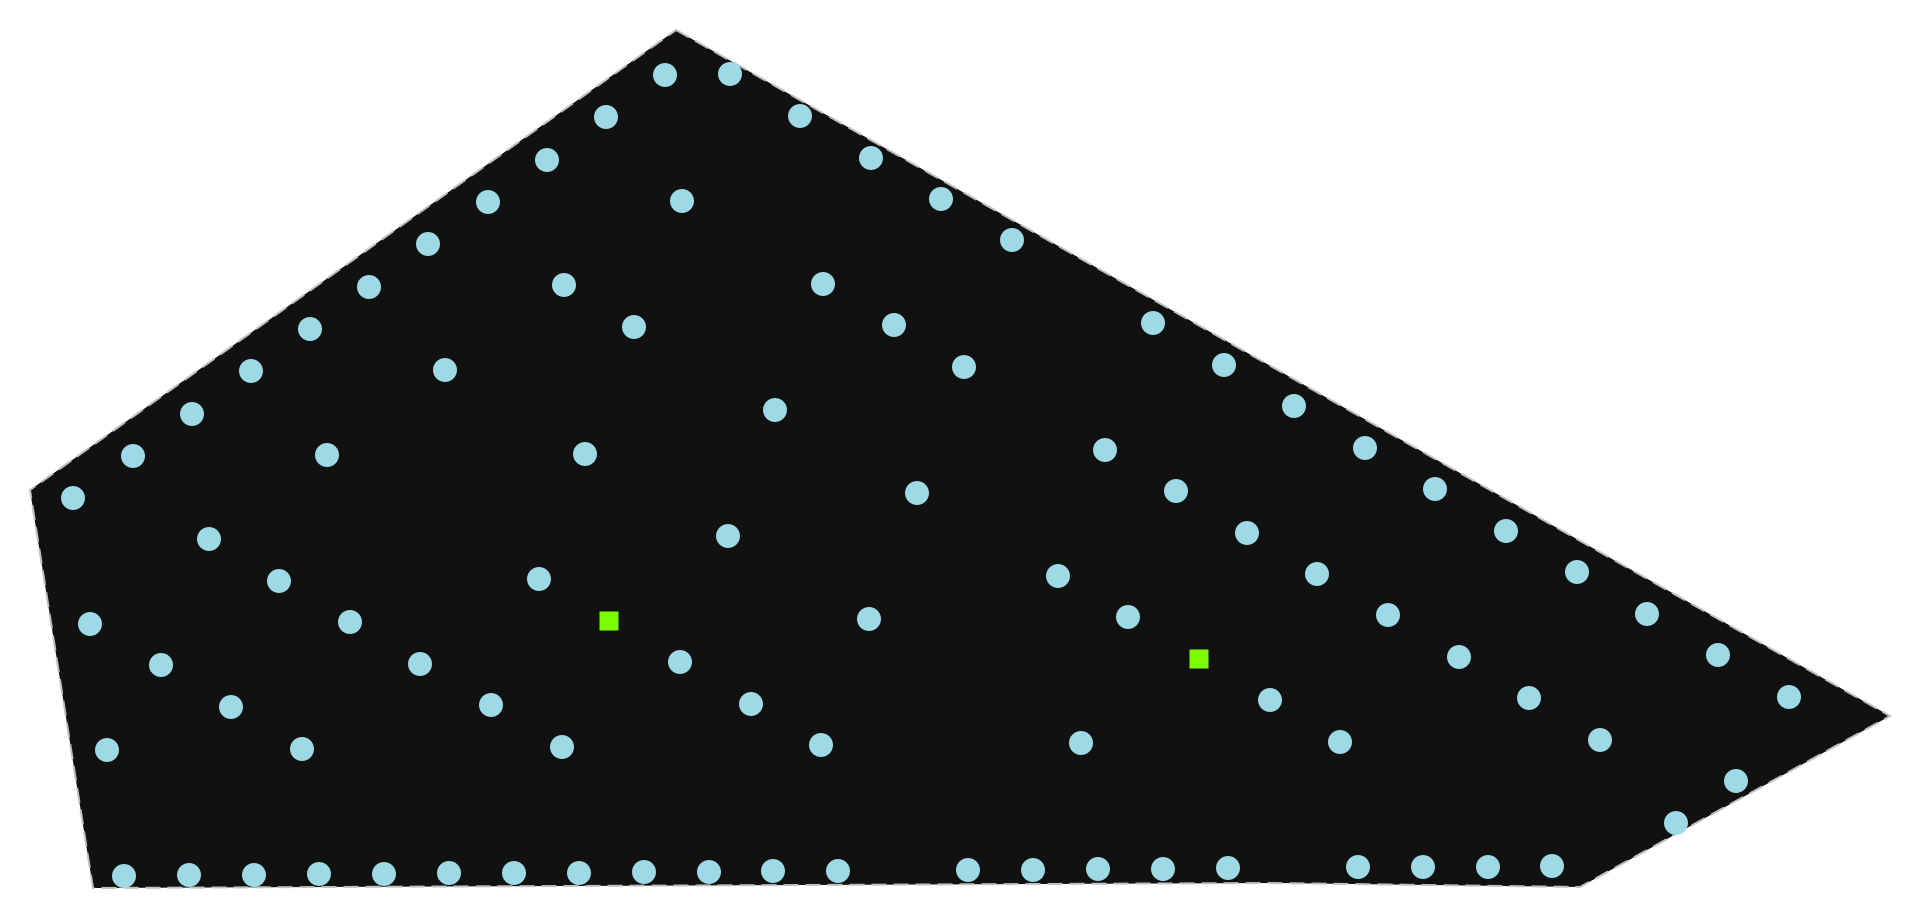

In [4]:
svgplot(L)

### Optimize Triton

In [5]:
P, A = make_planar_embedding(L)

Initial heuristic solution to warm-start the solver:

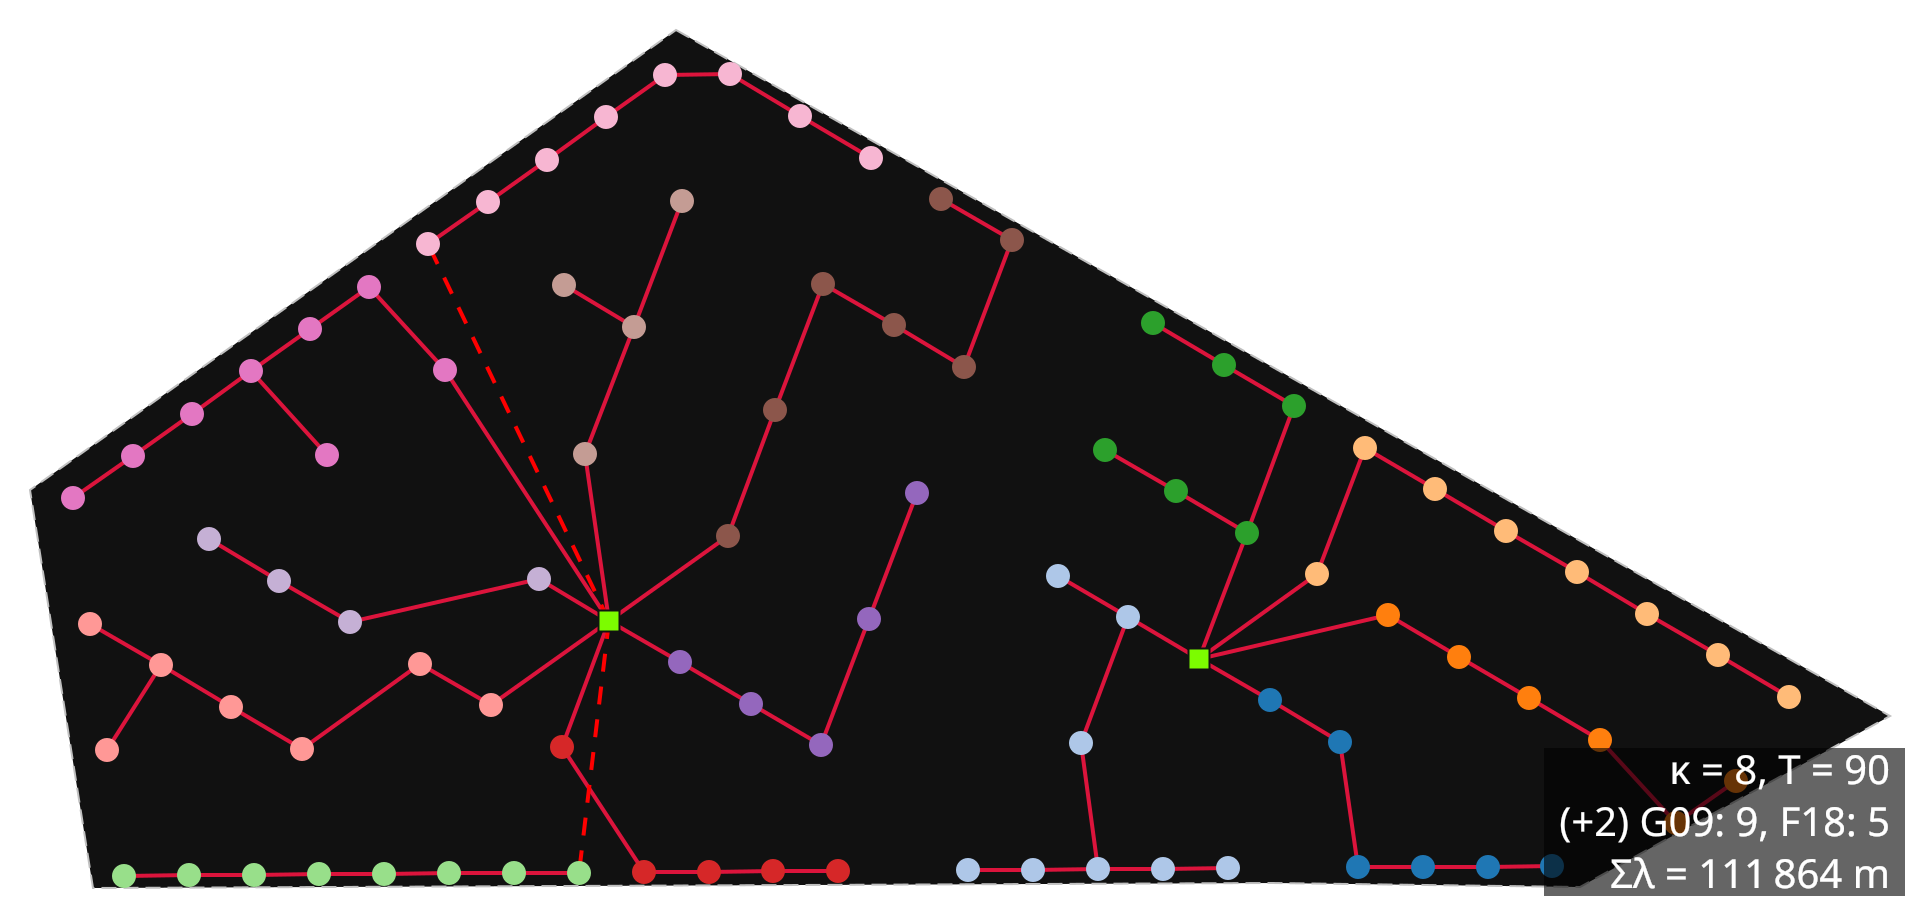

In [6]:
Sʹ = constructor(A, capacity=capacity)
Gʹ = G_from_S(Sʹ, A)
svgplot(Gʹ)

In [7]:
solver = solver_factory('highs')

In [8]:
solver.set_problem(
    P,
    A,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='unlimited',
    ),
    warmstart=Sʹ,
)

In [9]:
solver.solve(
    mip_gap=0.005,
    time_limit=60,
    verbose=True,
)

SolutionInfo(runtime=60.06334948539734, bound=105831.6512653093, objective=106958.32380043658, relgap=0.01053375272811341, termination='maxTimeLimit')

In [10]:
S, G = solver.get_solution()

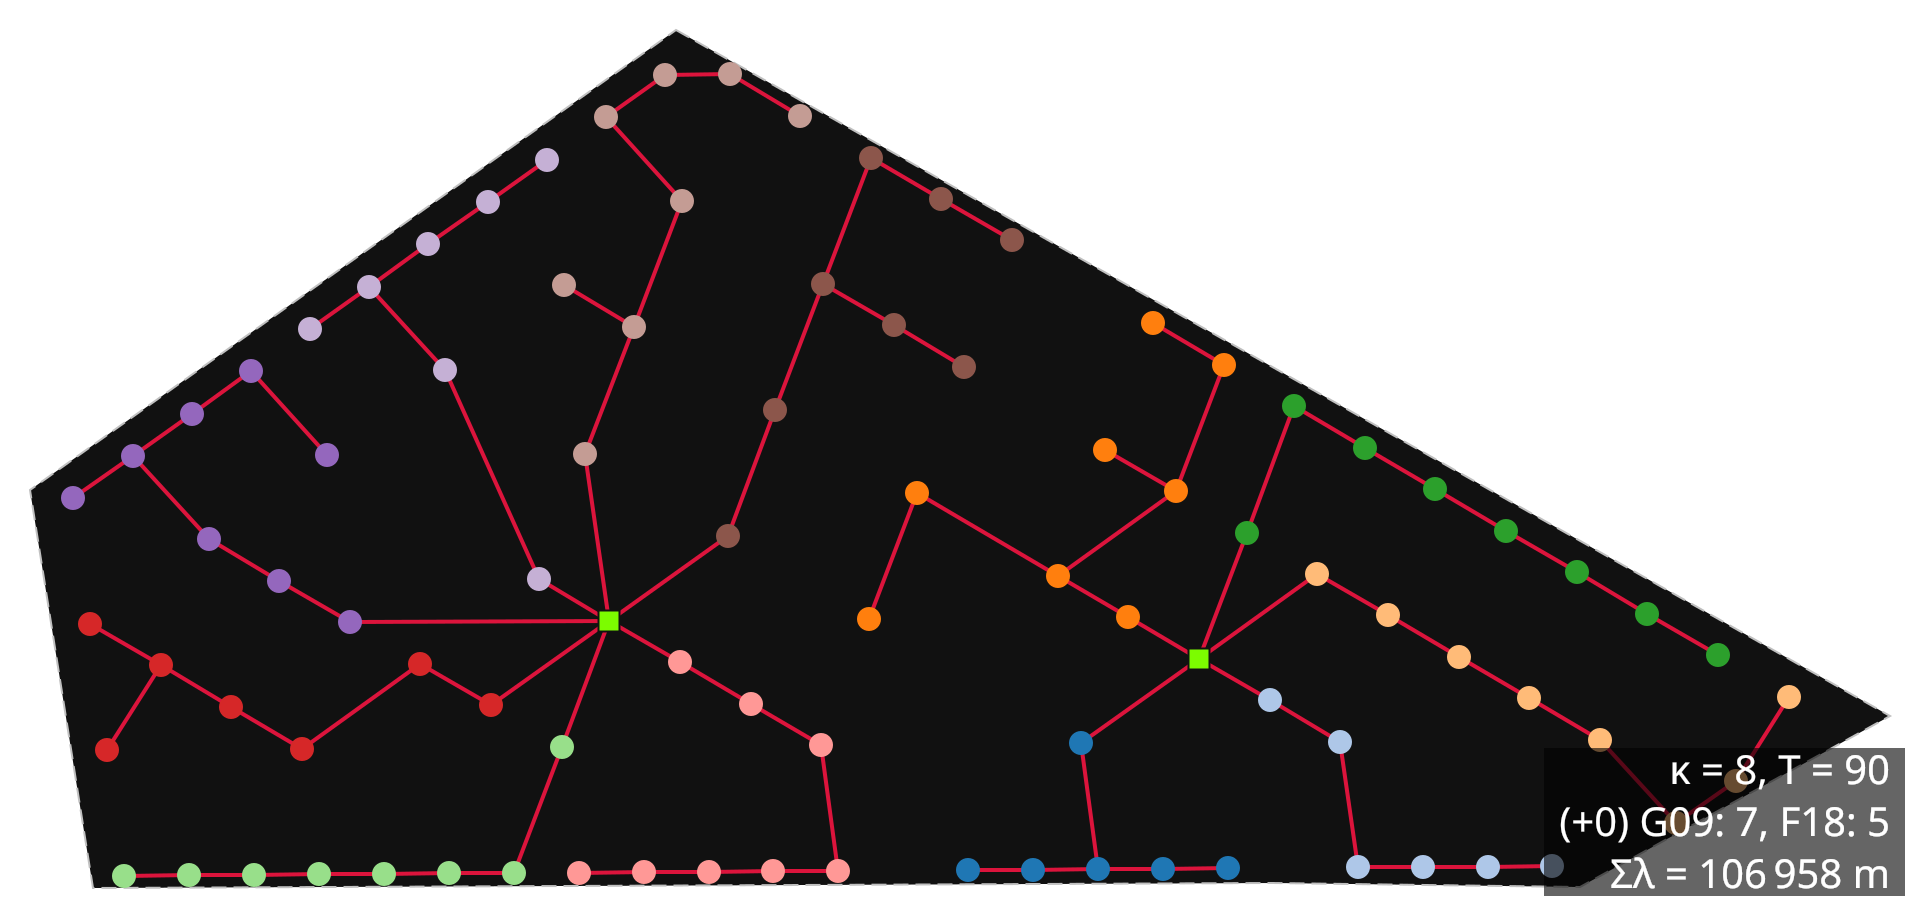

In [11]:
svgplot(G)